<a href="https://colab.research.google.com/github/Eng3mr5aled/Machine-Learning-_python/blob/main/Exercise_3_%E2%80%94_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix

In [ ]:
titanic = pd.read_csv('titanic.csv')
print('Shape:', titanic.shape)
titanic.head()

Shape: (891, 5)


,Pclass,Sex,Age,Fare,Survived
0,2,1,60,8.46,1
1,3,1,22,27.62,0
2,3,1,40,17.49,0
3,3,1,34,22.62,1
4,1,0,48,38.05,1


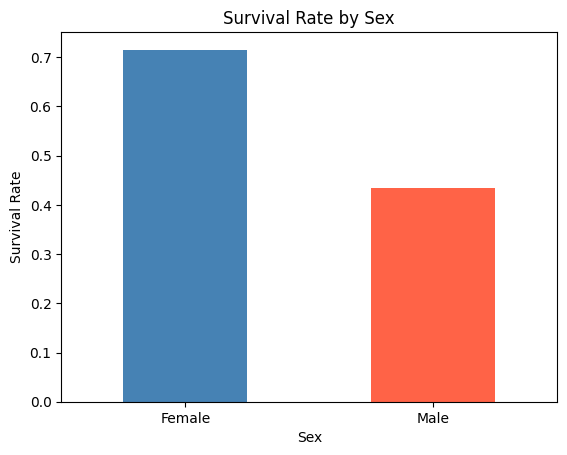

In [ ]:
# Survival rate by Sex
titanic.groupby('Sex')['Survived'].mean().rename({0: 'Female', 1: 'Male'}).plot(kind='bar', color=['steelblue', 'tomato'])
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Sex')
plt.xticks(rotation=0)
plt.show()

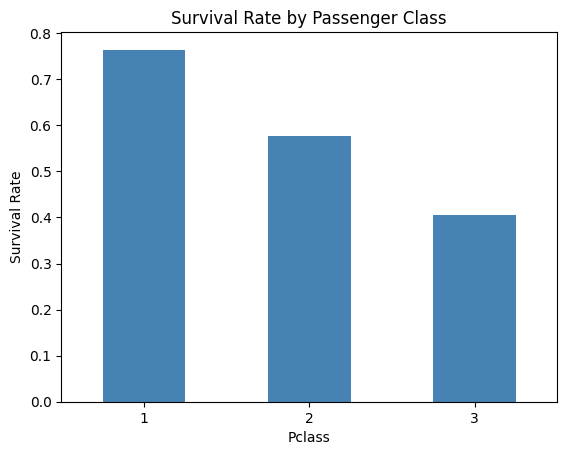

In [ ]:
# Survival rate by Pclass
titanic.groupby('Pclass')['Survived'].mean().plot(kind='bar', color='steelblue')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Passenger Class')
plt.xticks(rotation=0)
plt.show()

In [ ]:
features = ['Pclass', 'Sex', 'Age', 'Fare']

X_t = titanic[features]
y_t = titanic['Survived']

X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

# Scale features — important for logistic regression
scaler = StandardScaler()
X_tr_t_scaled = scaler.fit_transform(X_tr_t)
X_te_t_scaled = scaler.transform(X_te_t)

In [ ]:
log_model = LogisticRegression()
log_model.fit(X_tr_t_scaled, y_tr_t)

print('Coefficients:')
for feat, coef in zip(features, log_model.coef_[0]):
    print(f'  {feat:<8}: {coef:>7.3f}')
print(f'  Intercept: {log_model.intercept_[0]:.3f}')

Coefficients:
  Pclass  :  -0.491
  Sex     :  -0.621
  Age     :  -0.292
  Fare    :   0.277
  Intercept: 0.144


In [ ]:
y_pred_t = log_model.predict(X_te_t_scaled)

accuracy = accuracy_score(y_te_t, y_pred_t)
print(f'Accuracy: {accuracy:.4f}  ({accuracy*100:.1f}% of passengers correctly classified)')

Accuracy: 0.7430  (74.3% of passengers correctly classified)


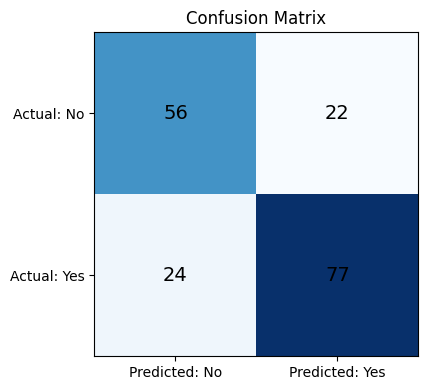

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_te_t, y_pred_t)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: No', 'Predicted: Yes'])
ax.set_yticklabels(['Actual: No', 'Actual: Yes'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14, color='black')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Predict probability for a new passenger
# 1st class, female, age 29, fare 80
new_passenger = scaler.transform([[3, 1, 22, 8]])
prob = log_model.predict_proba(new_passenger)[0][1]
print(f'Survival probability: {prob:.2%}')

Survival probability: 33.06%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
